+ Atividade 1: Carregamento e PCA

In [1]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80)

# data (as pandas dataframes)
X = optical_recognition_of_handwritten_digits.data.features
y = optical_recognition_of_handwritten_digits.data.targets

# metadata
print(optical_recognition_of_handwritten_digits.metadata)

# variable information
print(optical_recognition_of_handwritten_digits.variables)

{'uci_id': 80, 'name': 'Optical Recognition of Handwritten Digits', 'repository_url': 'https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits', 'data_url': 'https://archive.ics.uci.edu/static/public/80/data.csv', 'abstract': 'Two versions of this database available; see folder', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 5620, 'num_features': 64, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Wed Aug 23 2023', 'dataset_doi': '10.24432/C50P49', 'creators': ['E. Alpaydin', 'C. Kaynak'], 'intro_paper': {'ID': 280, 'type': 'NATIVE', 'title': 'Methods of Combining Multiple Classifiers and Their Applications to Handwritten Digit Recognition', 'authors': 'C. Kaynak', 'venue': 'MSc Thesis, Institute of Graduate Studies in Science and Engineering, 

+ Atividade 2: Dados para Treino

In [5]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pickle

# 1. Dados
digits = fetch_ucirepo(id=80)
X, y = digits.data.features, digits.data.targets.values.ravel()

# 2. Divisão (Estratificada, 1/3 para teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y, random_state=42)

# 3. PCA e Treino K-Means (Atividade 1 e 2)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

modelo = KMeans(n_clusters=10, random_state=42, n_init='auto')
modelo.fit(X_train_pca)

# 4. Guardar
pickle.dump(modelo, open("modelo.pkl", "wb"))
pickle.dump(pca, open("pca.pkl", "wb"))
pickle.dump((X_test, y_test), open("teste.pkl", "wb"))
print("Treino concluído.")

Treino concluído.


+ Dados de teste

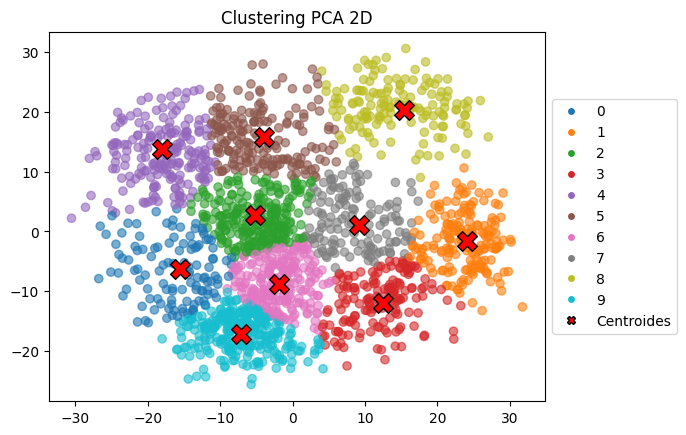

In [11]:
import pickle, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

modelo = pickle.load(open("modelo.pkl", "rb"))
pca = pickle.load(open("pca.pkl", "rb"))
X_test, _ = pickle.load(open("teste.pkl", "rb"))

X = pca.transform(X_test)
y = modelo.predict(X)
c = modelo.cluster_centers_
cmap = plt.cm.tab10

plt.scatter(X[:,0], X[:,1], c=y, cmap=cmap, alpha=0.6)
plt.scatter(c[:,0], c[:,1], marker="X", s=200, c="red", edgecolors="black")

leg = [Line2D([0],[0], marker='o', color='w',
       markerfacecolor=cmap(i), label=str(i)) for i in range(10)]

leg += [Line2D([0],[0], marker='X', color='w',
        markerfacecolor='red', markeredgecolor='black',
        label='Centroides')]

plt.legend(handles=leg, bbox_to_anchor=(1,0.5), loc="center left")
plt.title("Clustering PCA 2D")
plt.show()

+ Prediçõa

In [7]:
from ucimlrepo import fetch_ucirepo
import pickle

# 1. Carregar
modelo = pickle.load(open("modelo.pkl", "rb"))
pca = pickle.load(open("pca.pkl", "rb"))

# 2. Dados
digits = fetch_ucirepo(id=80)
X, y = digits.data.features, digits.data.targets


novo = X.iloc[[12]]
novo_pca = pca.transform(novo)

# 4. Resultado
print("Previsão:", modelo.predict(novo_pca)[0])
print("Dígito Real impresso:", y.iloc[12].values[0])

Previsão: 5
Dígito Real impresso: 9
